In [1]:
import pandas as pd

transactions = pd.read_parquet('data/credit_card_transactions-ibm_v2.parquet')
cards = pd.read_parquet('data/sd254_cards.parquet')
users = pd.read_parquet('data/sd254_users.parquet')


In [2]:
cards

,User,CARD INDEX,Card Brand,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
0,0,0,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,0,1,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,0,2,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,0,3,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,0,4,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,1997,1,Amex,Credit,300609782832003,01/2024,663,YES,1,$6900,11/2000,2013,No
6142,1997,2,Visa,Credit,4718517475996018,01/2021,492,YES,2,$5700,04/2012,2012,No
6143,1998,0,Mastercard,Credit,5929512204765914,08/2020,237,NO,2,$9200,02/2012,2012,No
6144,1999,0,Mastercard,Debit,5589768928167462,01/2020,630,YES,1,$28074,01/2020,2020,No


In [3]:
users

,Person,Current Age,Retirement Age,Birth Year,Birth Month,Gender,Address,Apartment,City,State,Zipcode,Latitude,Longitude,Per Capita Income - Zipcode,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards
0,Hazel Robinson,53,66,1966,11,Female,462 Rose Lane,NaN,La Verne,CA,91750,34.15,-117.76,$29278,$59696,$127613,787,5
1,Sasha Sadr,53,68,1966,12,Female,3606 Federal Boulevard,NaN,Little Neck,NY,11363,40.76,-73.74,$37891,$77254,$191349,701,5
2,Saanvi Lee,81,67,1938,11,Female,766 Third Drive,NaN,West Covina,CA,91792,34.02,-117.89,$22681,$33483,$196,698,5
3,Everlee Clark,63,63,1957,1,Female,3 Madison Street,NaN,New York,NY,10069,40.71,-73.99,$163145,$249925,$202328,722,4
4,Kyle Peterson,43,70,1976,9,Male,9620 Valley Stream Drive,NaN,San Francisco,CA,94117,37.76,-122.44,$53797,$109687,$183855,675,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Jose Faraday,32,70,1987,7,Male,6577 Lexington Lane,9.0,Freeport,NY,11520,40.65,-73.58,$23550,$48010,$87837,703,3
1996,Ximena Richardson,62,65,1957,11,Female,2 Elm Drive,955.0,Independence,KY,41051,38.95,-84.54,$24218,$49378,$104480,740,4
1997,Annika Russell,47,67,1973,1,Female,276 Fifth Boulevard,NaN,Elizabeth,NJ,7201,40.66,-74.19,$15175,$30942,$71066,779,3
1998,Juelz Roman,66,60,1954,2,Male,259 Valley Boulevard,NaN,Camp Hill,PA,17011,40.24,-76.92,$25336,$54654,$27241,618,1


In [4]:
transactions

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,None,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,None,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,None,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,None,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,None,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386895,1999,1,2020,2,27,22:23,$-54.00,Chip Transaction,-5162038175624867091,Merrimack,NH,3054.0,5541,None,No
24386896,1999,1,2020,2,27,22:24,$54.00,Chip Transaction,-5162038175624867091,Merrimack,NH,3054.0,5541,None,No
24386897,1999,1,2020,2,28,07:43,$59.15,Chip Transaction,2500998799892805156,Merrimack,NH,3054.0,4121,None,No
24386898,1999,1,2020,2,28,20:10,$43.12,Chip Transaction,2500998799892805156,Merrimack,NH,3054.0,4121,None,No


In [5]:
users['User'] = users.index

data = transactions.merge(users, on='User', how='left')
cards = cards.rename(columns={'CARD INDEX': 'Card'})

all_data = data.merge(cards, on=['User', 'Card'], how='left')

all_data

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,...,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386895,1999,1,2020,2,27,22:23,$-54.00,Chip Transaction,-5162038175624867091,Merrimack,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386896,1999,1,2020,2,27,22:24,$54.00,Chip Transaction,-5162038175624867091,Merrimack,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386897,1999,1,2020,2,28,07:43,$59.15,Chip Transaction,2500998799892805156,Merrimack,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386898,1999,1,2020,2,28,20:10,$43.12,Chip Transaction,2500998799892805156,Merrimack,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No


pasiskaiciuojam kiek procentu fraud

In [6]:
mask= all_data['Is Fraud?'] == "Yes"
fraud_transactions = all_data.loc[mask]
len_fraud = len(fraud_transactions)
len_non_fraud = len(all_data) - len_fraud
print("Fraud transactions:", len_fraud)
print("Non fraud transactions:", len_non_fraud)

print("percentage of fraud transactions:", len_fraud / len(all_data) * 100)

Fraud transactions: 29757
Non fraud transactions: 24357143
percentage of fraud transactions: 0.12202042900081601


tiriam tik online transakcijas

In [7]:
mask = all_data["Merchant City"] == 'ONLINE'
data = all_data.loc[mask].copy()
data

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,...,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
11,0,0,2002,9,5,20:41,$53.91,Online Transaction,-9092677072201095172,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
24,0,0,2002,9,9,20:02,$144.90,Online Transaction,-8338381919281017248,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
85,0,0,2002,9,30,06:21,$127.32,Online Transaction,-7421093378627544099,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
99,0,0,2002,10,6,06:14,$139.39,Online Transaction,-7421093378627544099,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
106,0,0,2002,10,9,08:16,$53.09,Online Transaction,-4956618006720593695,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,1999,1,2020,2,24,20:04,$55.79,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386879,1999,1,2020,2,25,07:06,$43.08,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386880,1999,1,2020,2,25,07:34,$43.76,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386884,1999,1,2020,2,26,07:43,$45.18,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No


pasiziurim kiek procentu fraud yra online transakcijpse

In [8]:
mask= data['Is Fraud?'] == "Yes"
fraud_transactions = data.loc[mask]
len_fraud = len(fraud_transactions)
len_non_fraud = len(data) - len_fraud
print("Fraud transactions:", len_fraud)
print("Non fraud transactions:", len_non_fraud)

print("percentage of fraud transactions:", len_fraud / len(data) * 100)

Fraud transactions: 18349
Non fraud transactions: 2702472
percentage of fraud transactions: 0.6743920309347803


pasiziurim kiek none  values turim transakcijose

In [9]:
missing = data.isna().sum()
print(missing)

User                                 0
Card                                 0
Year                                 0
Month                                0
Day                                  0
Time                                 0
Amount                               0
Use Chip                             0
Merchant Name                        0
Merchant City                        0
Merchant State                 2720821
Zip                            2720821
MCC                                  0
Errors?                        2659365
Is Fraud?                            0
Person                               0
Current Age                          0
Retirement Age                       0
Birth Year                           0
Birth Month                          0
Gender                               0
Address                              0
Apartment                      2020344
City                                 0
State                                0
Zipcode                  

kadangi Merchant State ir Zip neturi duomenu, o apartment neturi reiksmes, trinam situos stulpelius lauk

In [10]:
data.drop(columns = ['Merchant State', 'Zip', 'Apartment'], inplace = True)

In [11]:
data

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,...,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
11,0,0,2002,9,5,20:41,$53.91,Online Transaction,-9092677072201095172,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
24,0,0,2002,9,9,20:02,$144.90,Online Transaction,-8338381919281017248,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
85,0,0,2002,9,30,06:21,$127.32,Online Transaction,-7421093378627544099,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
99,0,0,2002,10,6,06:14,$139.39,Online Transaction,-7421093378627544099,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
106,0,0,2002,10,9,08:16,$53.09,Online Transaction,-4956618006720593695,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,1999,1,2020,2,24,20:04,$55.79,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386879,1999,1,2020,2,25,07:06,$43.08,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386880,1999,1,2020,2,25,07:34,$43.76,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386884,1999,1,2020,2,26,07:43,$45.18,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No


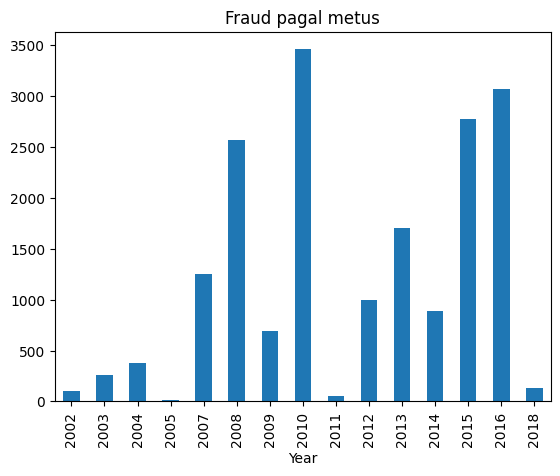

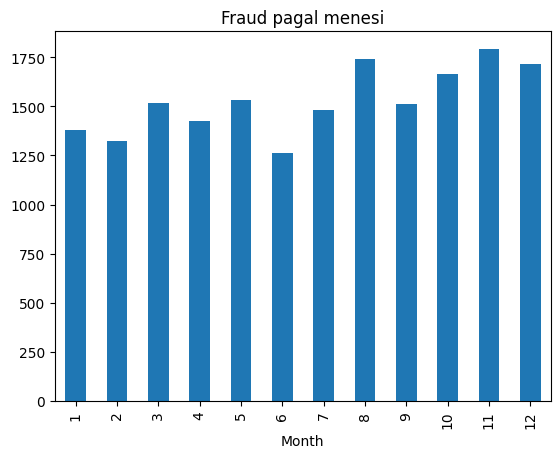

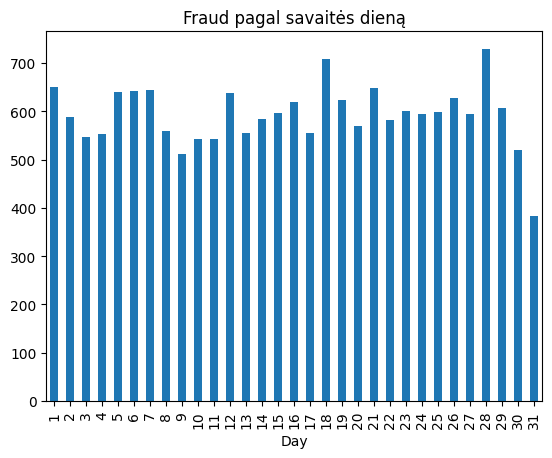

In [12]:
import matplotlib.pyplot as plt

fraud = data[data['Is Fraud?'] == 'Yes'].copy()

fraud.groupby('Year')['Is Fraud?'].count().plot(kind='bar')
plt.title('Fraud pagal metus')
plt.show()

fraud.groupby('Month')['Is Fraud?'].count().plot(kind='bar')
plt.title('Fraud pagal menesi')
plt.show()

fraud.groupby('Day')['Is Fraud?'].count().plot(kind='bar')
plt.title('Fraud pagal savaitės dieną')
plt.show()



kadangi nenesa svarbios info, trinam:
Use Chip
Merchant City
Person
Current Age
Birth Month
Address
City
State
Latitude
Longitude
Card Number
Expires
CVV
Has Chip
Cards Issued
Acct Open Date
Year PIN last Changed
Card on Dark Web (visi no)
Time
Retirement Age
MCC
Merchant Name
Credit Limit
Card
User
Zipcode
Per Capita Income - Zipcode

reikia encodint: gender, card brand, card type

In [13]:
data

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,...,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
11,0,0,2002,9,5,20:41,$53.91,Online Transaction,-9092677072201095172,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
24,0,0,2002,9,9,20:02,$144.90,Online Transaction,-8338381919281017248,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
85,0,0,2002,9,30,06:21,$127.32,Online Transaction,-7421093378627544099,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
99,0,0,2002,10,6,06:14,$139.39,Online Transaction,-7421093378627544099,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
106,0,0,2002,10,9,08:16,$53.09,Online Transaction,-4956618006720593695,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,1999,1,2020,2,24,20:04,$55.79,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386879,1999,1,2020,2,25,07:06,$43.08,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386880,1999,1,2020,2,25,07:34,$43.76,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No
24386884,1999,1,2020,2,26,07:43,$45.18,Online Transaction,-6160036380778658394,ONLINE,...,Credit,4994011318343994,12/2020,120,YES,1,$14400,05/2017,2017,No


In [14]:
cols_to_drop = '''
Use Chip
Merchant City
Person
Current Age
Birth Month
Address
City
State
Latitude
Longitude
Card Number
Expires
CVV
Has Chip
Cards Issued
Acct Open Date
Year PIN last Changed
Card on Dark Web
Time
Retirement Age
MCC
Merchant Name
Credit Limit
Card
User
Zipcode
Per Capita Income - Zipcode
'''.strip().splitlines()

cols_to_drop = [col.strip() for col in cols_to_drop]

data.drop(columns=cols_to_drop, inplace=True)

In [15]:
data

,Year,Month,Day,Amount,Errors?,Is Fraud?,Birth Year,Gender,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards,Card Brand,Card Type
11,2002,9,5,$53.91,None,No,1966,Female,$59696,$127613,787,5,Visa,Debit
24,2002,9,9,$144.90,None,No,1966,Female,$59696,$127613,787,5,Visa,Debit
85,2002,9,30,$127.32,None,No,1966,Female,$59696,$127613,787,5,Visa,Debit
99,2002,10,6,$139.39,None,No,1966,Female,$59696,$127613,787,5,Visa,Debit
106,2002,10,9,$53.09,None,No,1966,Female,$59696,$127613,787,5,Visa,Debit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,2020,2,24,$55.79,None,No,1998,Female,$65909,$181261,673,2,Visa,Credit
24386879,2020,2,25,$43.08,None,No,1998,Female,$65909,$181261,673,2,Visa,Credit
24386880,2020,2,25,$43.76,None,No,1998,Female,$65909,$181261,673,2,Visa,Credit
24386884,2020,2,26,$45.18,None,No,1998,Female,$65909,$181261,673,2,Visa,Credit


In [16]:
mask = data["Errors?"].isna()
data.loc[mask, "Errors?"] = False
data.loc[~mask, "Errors?"] = True
data

,Year,Month,Day,Amount,Errors?,Is Fraud?,Birth Year,Gender,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards,Card Brand,Card Type
11,2002,9,5,$53.91,False,No,1966,Female,$59696,$127613,787,5,Visa,Debit
24,2002,9,9,$144.90,False,No,1966,Female,$59696,$127613,787,5,Visa,Debit
85,2002,9,30,$127.32,False,No,1966,Female,$59696,$127613,787,5,Visa,Debit
99,2002,10,6,$139.39,False,No,1966,Female,$59696,$127613,787,5,Visa,Debit
106,2002,10,9,$53.09,False,No,1966,Female,$59696,$127613,787,5,Visa,Debit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,2020,2,24,$55.79,False,No,1998,Female,$65909,$181261,673,2,Visa,Credit
24386879,2020,2,25,$43.08,False,No,1998,Female,$65909,$181261,673,2,Visa,Credit
24386880,2020,2,25,$43.76,False,No,1998,Female,$65909,$181261,673,2,Visa,Credit
24386884,2020,2,26,$45.18,False,No,1998,Female,$65909,$181261,673,2,Visa,Credit


In [17]:
un = transactions["Errors?"].unique()
print(un)

[None 'Technical Glitch' 'Insufficient Balance' 'Bad PIN'
 'Bad PIN,Insufficient Balance' 'Bad Expiration'
 'Bad PIN,Technical Glitch' 'Bad Card Number' 'Bad CVV' 'Bad Zipcode'
 'Insufficient Balance,Technical Glitch'
 'Bad Card Number,Insufficient Balance' 'Bad Card Number,Bad CVV'
 'Bad CVV,Insufficient Balance' 'Bad Card Number,Bad Expiration'
 'Bad Expiration,Bad CVV' 'Bad Expiration,Insufficient Balance'
 'Bad Expiration,Technical Glitch'
 'Bad Card Number,Bad Expiration,Technical Glitch'
 'Bad CVV,Technical Glitch' 'Bad Card Number,Technical Glitch'
 'Bad Zipcode,Insufficient Balance' 'Bad Zipcode,Technical Glitch'
 'Bad Card Number,Bad Expiration,Insufficient Balance']


In [18]:
mask = ~(data['Errors?'].isna()) & (data['Is Fraud?'] == 'Yes')
test = data.loc[mask].copy()
test


,Year,Month,Day,Amount,Errors?,Is Fraud?,Birth Year,Gender,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards,Card Brand,Card Type
4099,2015,11,15,$287.13,False,Yes,1966,Female,$59696,$127613,787,5,Visa,Debit
4100,2015,11,15,$2.41,False,Yes,1966,Female,$59696,$127613,787,5,Visa,Debit
4101,2015,11,16,$50.81,False,Yes,1966,Female,$59696,$127613,787,5,Visa,Debit
4102,2015,11,16,$248.36,False,Yes,1966,Female,$59696,$127613,787,5,Visa,Debit
4103,2015,11,16,$473.00,False,Yes,1966,Female,$59696,$127613,787,5,Visa,Debit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24375668,2016,9,4,$1.25,False,Yes,1973,Female,$30942,$71066,779,3,Visa,Credit
24375670,2016,9,4,$116.66,False,Yes,1973,Female,$30942,$71066,779,3,Visa,Credit
24375671,2016,9,4,$359.99,False,Yes,1973,Female,$30942,$71066,779,3,Visa,Credit
24375672,2016,9,4,$351.51,False,Yes,1973,Female,$30942,$71066,779,3,Visa,Credit


In [19]:
mask = ~(data['Errors?'].isna()) & (data['Is Fraud?'] == 'No')
test = data.loc[mask].copy()
test


,Year,Month,Day,Amount,Errors?,Is Fraud?,Birth Year,Gender,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards,Card Brand,Card Type
11,2002,9,5,$53.91,False,No,1966,Female,$59696,$127613,787,5,Visa,Debit
24,2002,9,9,$144.90,False,No,1966,Female,$59696,$127613,787,5,Visa,Debit
85,2002,9,30,$127.32,False,No,1966,Female,$59696,$127613,787,5,Visa,Debit
99,2002,10,6,$139.39,False,No,1966,Female,$59696,$127613,787,5,Visa,Debit
106,2002,10,9,$53.09,False,No,1966,Female,$59696,$127613,787,5,Visa,Debit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,2020,2,24,$55.79,False,No,1998,Female,$65909,$181261,673,2,Visa,Credit
24386879,2020,2,25,$43.08,False,No,1998,Female,$65909,$181261,673,2,Visa,Credit
24386880,2020,2,25,$43.76,False,No,1998,Female,$65909,$181261,673,2,Visa,Credit
24386884,2020,2,26,$45.18,False,No,1998,Female,$65909,$181261,673,2,Visa,Credit


In [21]:
from decimal import Decimal

data['Yearly Income - Person'] = data['Yearly Income - Person'].str.replace('$', '', regex=False).apply(Decimal)
data['Total Debt'] = data['Total Debt'].str.replace('$', '', regex=False).apply(Decimal)
data['Amount'] = data['Amount'].str.replace('$', '', regex=False).apply(Decimal)


In [22]:
data

,Year,Month,Day,Amount,Errors?,Is Fraud?,Birth Year,Gender,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards,Card Brand,Card Type
11,2002,9,5,53.91,False,No,1966,Female,59696,127613,787,5,Visa,Debit
24,2002,9,9,144.90,False,No,1966,Female,59696,127613,787,5,Visa,Debit
85,2002,9,30,127.32,False,No,1966,Female,59696,127613,787,5,Visa,Debit
99,2002,10,6,139.39,False,No,1966,Female,59696,127613,787,5,Visa,Debit
106,2002,10,9,53.09,False,No,1966,Female,59696,127613,787,5,Visa,Debit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,2020,2,24,55.79,False,No,1998,Female,65909,181261,673,2,Visa,Credit
24386879,2020,2,25,43.08,False,No,1998,Female,65909,181261,673,2,Visa,Credit
24386880,2020,2,25,43.76,False,No,1998,Female,65909,181261,673,2,Visa,Credit
24386884,2020,2,26,45.18,False,No,1998,Female,65909,181261,673,2,Visa,Credit


In [23]:
mask = data['Gender'] == "Female"
data.loc[mask, 'Gender'] = 1

mask = data['Gender'] == "Male"
data.loc[mask, 'Gender'] = 2


In [24]:
mask = data['Card Brand'] == "Visa"
data.loc[mask, 'Card Brand'] = 1

mask = data['Card Brand'] == "Mastercard"
data.loc[mask, 'Card Brand'] = 2

mask = data['Card Brand'] == "Amex"
data.loc[mask, 'Card Brand'] = 3

mask = data['Card Brand'] == "Discover"
data.loc[mask, 'Card Brand'] = 4


In [25]:
mask = data['Card Type'] == "Debit"
data.loc[mask, 'Card Type'] = 1

mask = data['Card Type'] == "Credit"
data.loc[mask, 'Card Type'] = 2

mask = data['Card Type'] == "Debit (Prepaid)"
data.loc[mask, 'Card Type'] = 3


In [26]:
mask = data['Errors?'] == True
data.loc[mask, 'Errors?'] = 1

mask = data['Errors?'] == False
data.loc[mask, 'Errors?'] = 0

In [27]:
mask = data['Is Fraud?'] == "Yes"
data.loc[mask, 'Is Fraud?'] = 1

mask = data['Is Fraud?'] == "No"
data.loc[mask, 'Is Fraud?'] = 0

In [28]:
data

,Year,Month,Day,Amount,Errors?,Is Fraud?,Birth Year,Gender,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards,Card Brand,Card Type
11,2002,9,5,53.91,0,0,1966,1,59696,127613,787,5,1,1
24,2002,9,9,144.90,0,0,1966,1,59696,127613,787,5,1,1
85,2002,9,30,127.32,0,0,1966,1,59696,127613,787,5,1,1
99,2002,10,6,139.39,0,0,1966,1,59696,127613,787,5,1,1
106,2002,10,9,53.09,0,0,1966,1,59696,127613,787,5,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,2020,2,24,55.79,0,0,1998,1,65909,181261,673,2,1,2
24386879,2020,2,25,43.08,0,0,1998,1,65909,181261,673,2,1,2
24386880,2020,2,25,43.76,0,0,1998,1,65909,181261,673,2,1,2
24386884,2020,2,26,45.18,0,0,1998,1,65909,181261,673,2,1,2


In [29]:
for col in data.columns:
    if data[col].dtype == 'object':
        try:
            data[col] = pd.to_numeric(data[col], errors='coerce')
            print(f"{col} konvertuota")
        except:
            print(f"{col} nekonvertuota")

Amount konvertuota
Errors? konvertuota
Is Fraud? konvertuota
Gender konvertuota
Yearly Income - Person konvertuota
Total Debt konvertuota
Card Brand konvertuota
Card Type konvertuota


In [30]:
data

,Year,Month,Day,Amount,Errors?,Is Fraud?,Birth Year,Gender,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards,Card Brand,Card Type
11,2002,9,5,53.91,0,0,1966,1,59696.0,127613.0,787,5,1,1
24,2002,9,9,144.90,0,0,1966,1,59696.0,127613.0,787,5,1,1
85,2002,9,30,127.32,0,0,1966,1,59696.0,127613.0,787,5,1,1
99,2002,10,6,139.39,0,0,1966,1,59696.0,127613.0,787,5,1,1
106,2002,10,9,53.09,0,0,1966,1,59696.0,127613.0,787,5,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,2020,2,24,55.79,0,0,1998,1,65909.0,181261.0,673,2,1,2
24386879,2020,2,25,43.08,0,0,1998,1,65909.0,181261.0,673,2,1,2
24386880,2020,2,25,43.76,0,0,1998,1,65909.0,181261.0,673,2,1,2
24386884,2020,2,26,45.18,0,0,1998,1,65909.0,181261.0,673,2,1,2


In [31]:
data['Age'] = data['Year'] - data['Birth Year']

In [ ]:
data

,Year,Month,Day,Amount,Errors?,Is Fraud?,Birth Year,Gender,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards,Card Brand,Card Type,Age
11,2002,9,5,53.91,0,0,1966,1,59696.0,127613.0,787,5,1,1,36
24,2002,9,9,144.90,0,0,1966,1,59696.0,127613.0,787,5,1,1,36
85,2002,9,30,127.32,0,0,1966,1,59696.0,127613.0,787,5,1,1,36
99,2002,10,6,139.39,0,0,1966,1,59696.0,127613.0,787,5,1,1,36
106,2002,10,9,53.09,0,0,1966,1,59696.0,127613.0,787,5,1,1,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386877,2020,2,24,55.79,0,0,1998,1,65909.0,181261.0,673,2,1,2,22
24386879,2020,2,25,43.08,0,0,1998,1,65909.0,181261.0,673,2,1,2,22
24386880,2020,2,25,43.76,0,0,1998,1,65909.0,181261.0,673,2,1,2,22
24386884,2020,2,26,45.18,0,0,1998,1,65909.0,181261.0,673,2,1,2,22


In [33]:
data.to_parquet('data/prepared_data.parquet', index=False)